# 데이터 불러오기

전처리했던 csv 파일로

In [1]:
import pandas as pd

file_path = '../data/Compensation_pre.csv'
data = pd.read_csv(file_path, index_col =0)
data

,지역,학교급,사고자구분,사고자학년,사고자성별,사고시간,사고장소,사고부위,사고형태,사고당시활동,추정나이,보상급여
0,전남,고등학교,일반학생,2학년,남,쉬는시간,강당(체육관),골반/엉덩이,그밖의 손상 사고,기타,17,31900
1,대구,초등학교,일반학생,6학년,여,체육,운동장,두피,그밖의 손상 사고,기타 스포츠 활동,12,53000
2,경남,고등학교,일반학생,1학년,남,그 밖의 교육활동 시간,기타 교외,기타,그밖의 손상 사고,기타,16,15027050
3,전북,초등학교,일반학생,5학년,남,쉬는시간,일반(교과)교실,어깨,그밖의 손상 사고,기타,11,3114900
4,제주,초등학교,일반학생,2학년,남,식사시간(간식 포함),기타 교외,치아,고정된 물체와의 부딪힘,기타,8,1106500
...,...,...,...,...,...,...,...,...,...,...,...,...
425209,서울,중학교,일반학생,3학년,여,체육,강당(체육관),손가락,고정된 물체와의 부딪힘,피구,15,97200
425210,서울,초등학교,일반학생,5학년,남,체육,강당(체육관),복합부위,사람과의 부딪힘,기타 구기,11,585950
425211,서울,기타학교,일반학생,3학년,여,현장학습,기타 교외,무릎,넘어짐,"걷기/뛰기, 오르내리기",18,0
425212,서울,기타학교,일반학생,2학년,여,쉬는시간,계단,어깨,넘어짐,"걷기/뛰기, 오르내리기",17,284910


- 이전 상관관계 중 0.5 이상을 확인

# 사고시간

In [2]:
def cross_tab_top3(df, col1, col2):
    import pandas as pd
    import matplotlib.pyplot as plt

    # col1 <-> col2 축 교체 및 비율 계산
    cross_tab = pd.crosstab(df[col2], df[col1], normalize='index')

    # 1️각 그룹별 top3 범주 구한 뒤 union
    top_categories_set = set()
    for bar_cat in cross_tab.index:
        group_row = cross_tab.loc[bar_cat]
        top3_categories = group_row.sort_values(ascending=False).head(3).index.tolist()
        top_categories_set.update(top3_categories)

    top_categories_list = list(top_categories_set)

    # 2️Stacked Horizontal Bar Chart
    ax = cross_tab.plot(kind='barh', stacked=True, figsize=(10, max(6, len(cross_tab)*0.5)), colormap='tab20')

    # 3️Legend를 top_categories_list만 표시
    handles, labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    filtered_handles = [label_to_handle[label] for label in labels if label in top_categories_list]
    filtered_labels = [label for label in labels if label in top_categories_list]

    ax.legend(filtered_handles, filtered_labels, title=col1, bbox_to_anchor=(1.05, 1))

    # 4️Annotate는 각 그룹별 top3만 표시
    for idx, bar_cat in enumerate(cross_tab.index):
        group_row = cross_tab.loc[bar_cat]
        top3_categories = group_row.sort_values(ascending=False).head(3).index.tolist()

        x_offset = 0
        for cat in cross_tab.columns:
            val = group_row[cat]
            if val > 0.01 and cat in top3_categories:
                ax.text(x_offset + val / 2,
                        idx,
                        f"{val*100:.1f}%",
                        ha='center', va='center',
                        fontsize=9, color='black')
            x_offset += val

    plt.xlabel('Proportion')
    plt.title(f'Stacked Horizontal Bar: Group-wise Top 3 Annot, Filtered Legend ({col2} vs {col1})')
    plt.tight_layout()
    plt.show()


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.__init__()

fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print("설치된 나눔폰트:", fonts)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

설치된 나눔폰트: ['NanumMyeongjo Eco', 'NanumGothicCoding', 'NanumSquare', 'NanumMyeongjo', 'NanumBarunGothic', 'NanumSquareRound', 'NanumSquare', 'NanumMyeongjo Eco', 'NanumSquare', 'NanumMyeongjo', 'NanumBarunpen', 'NanumGothic Eco', 'NanumSquare_ac', 'NanumMyeongjo Eco', 'NanumBarunpen', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumBarunGothic', 'NanumSquareRound', 'NanumGothic Eco', 'NanumSquare_ac', 'NanumSquare_ac', 'NanumSquareRound', 'NanumMyeongjo Eco', 'NanumSquareRound', 'Nanum Brush Script', 'NanumGothic Eco', 'NanumGothic Eco', 'NanumGothic', 'NanumGothic', 'NanumMyeongjo YetHangul', 'NanumSquare_ac', 'NanumBarunGothic YetHangul', 'NanumGothic', 'NanumBarunGothic', 'NanumBarunGothic', 'NanumSquare', 'Nanum Pen Script', 'NanumGothic']


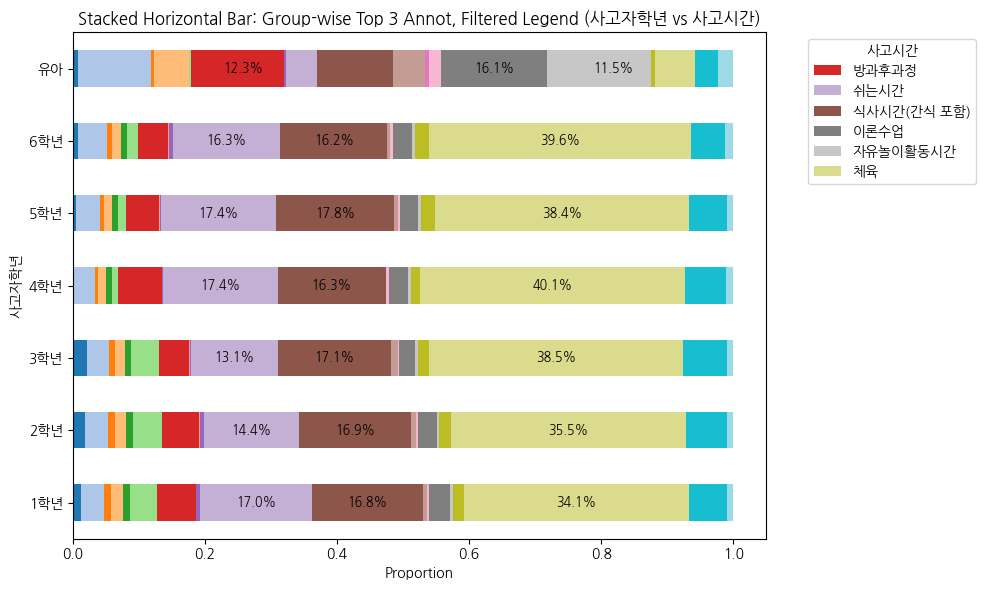

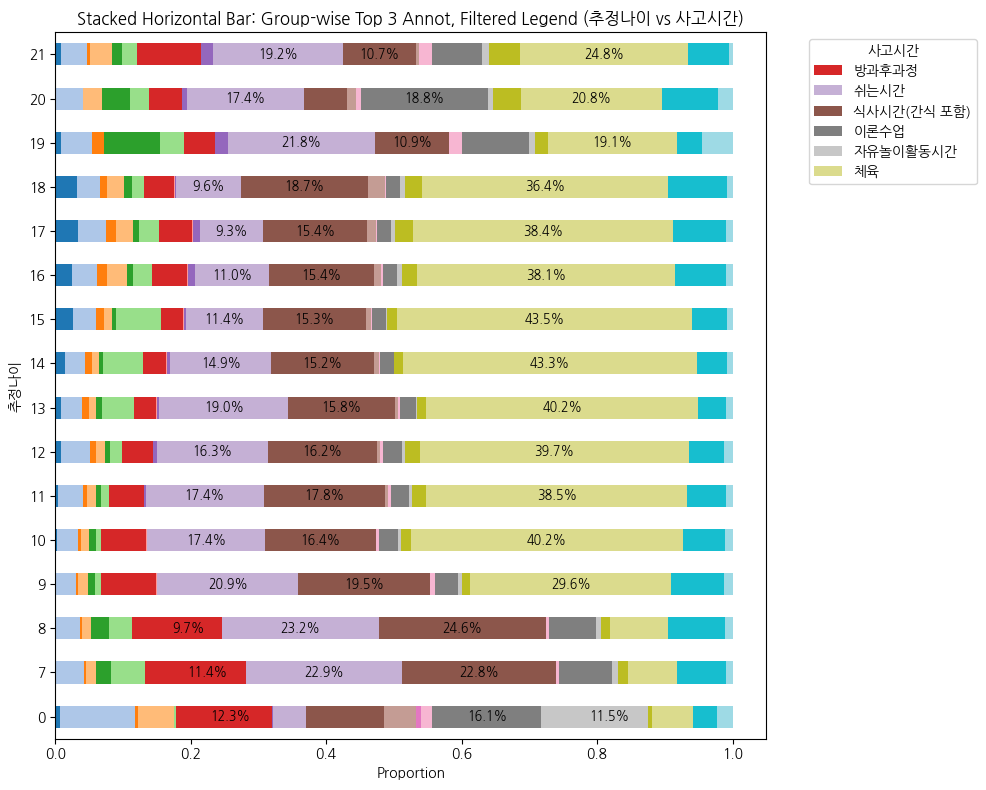

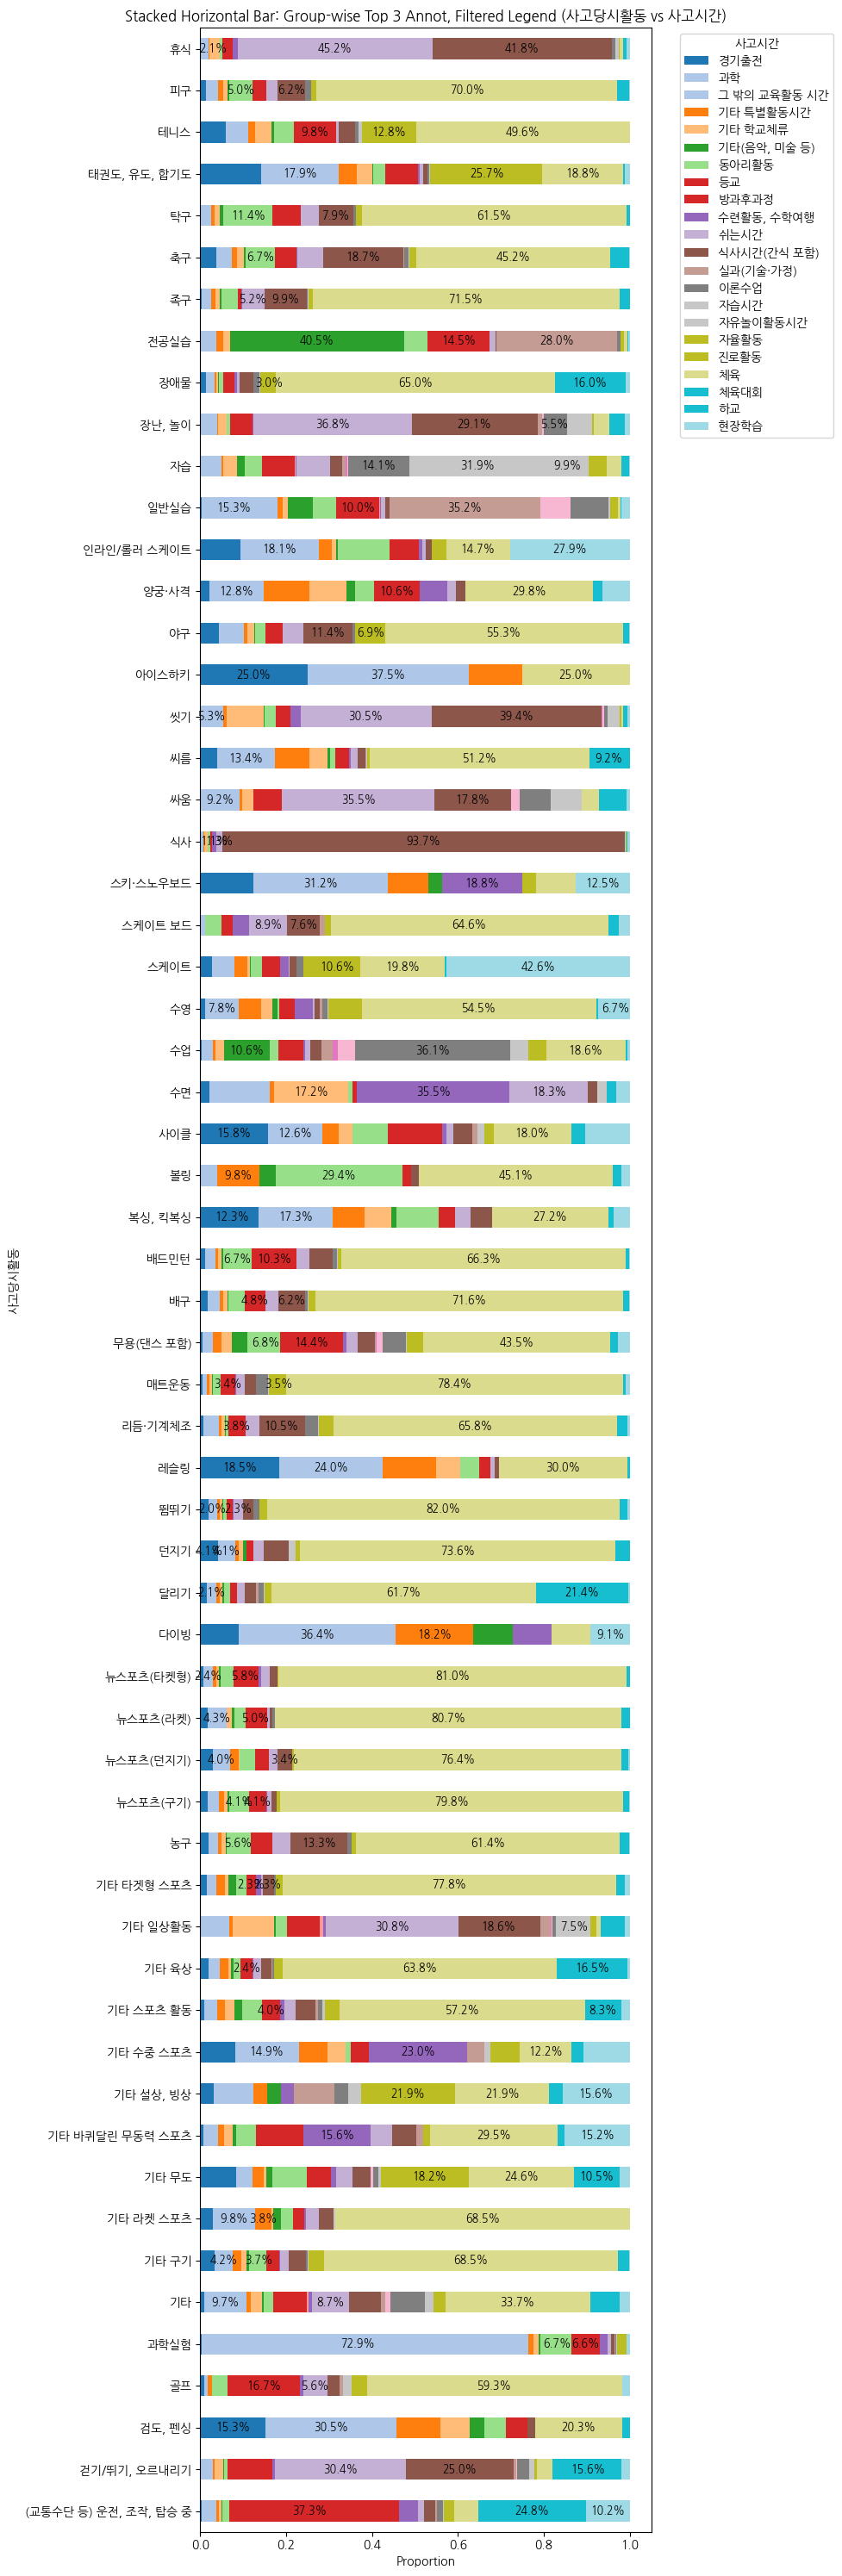

In [4]:
with_time = ['사고자학년', '추정나이', '사고당시활동']

for i in with_time:
    cross_tab_top3(data, '사고시간', i)

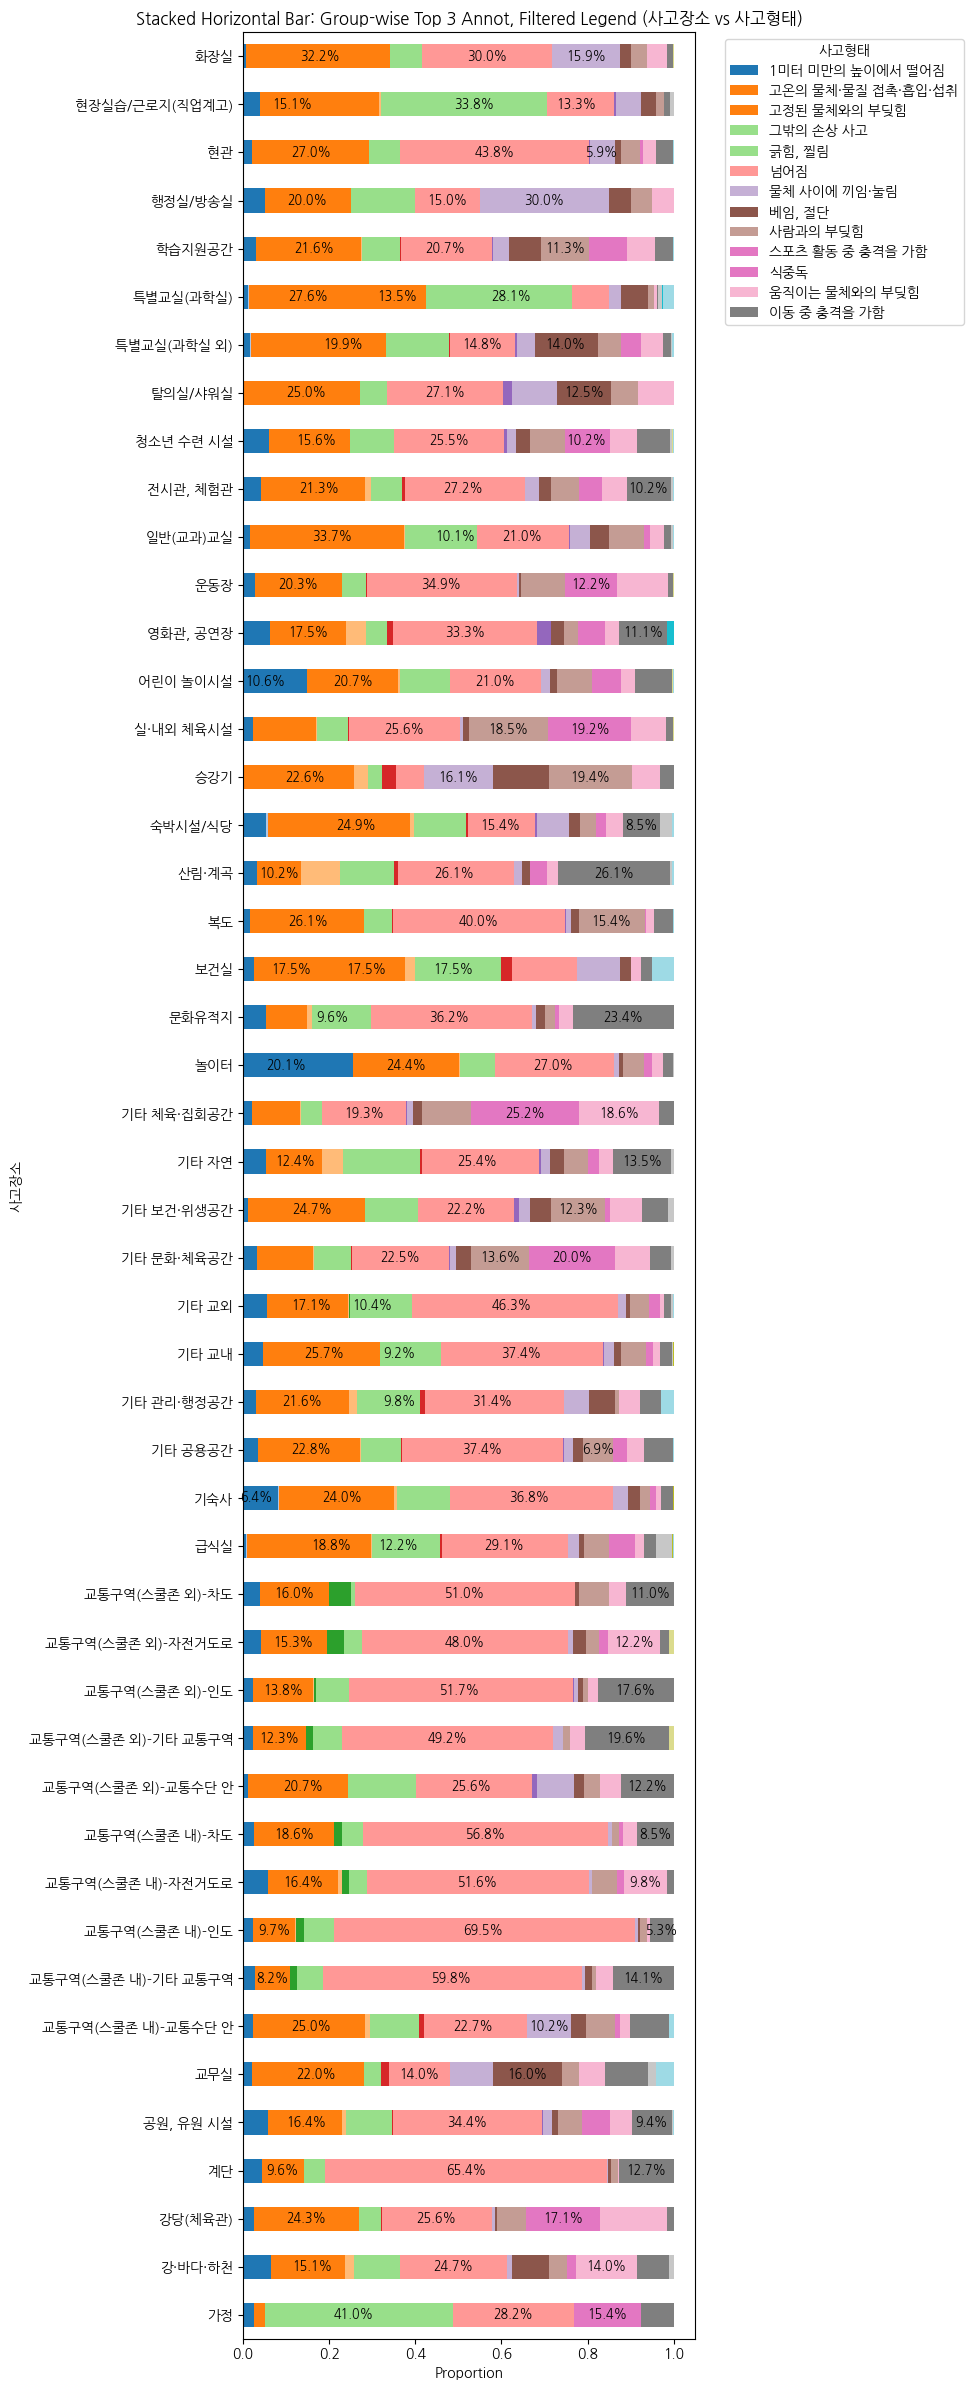

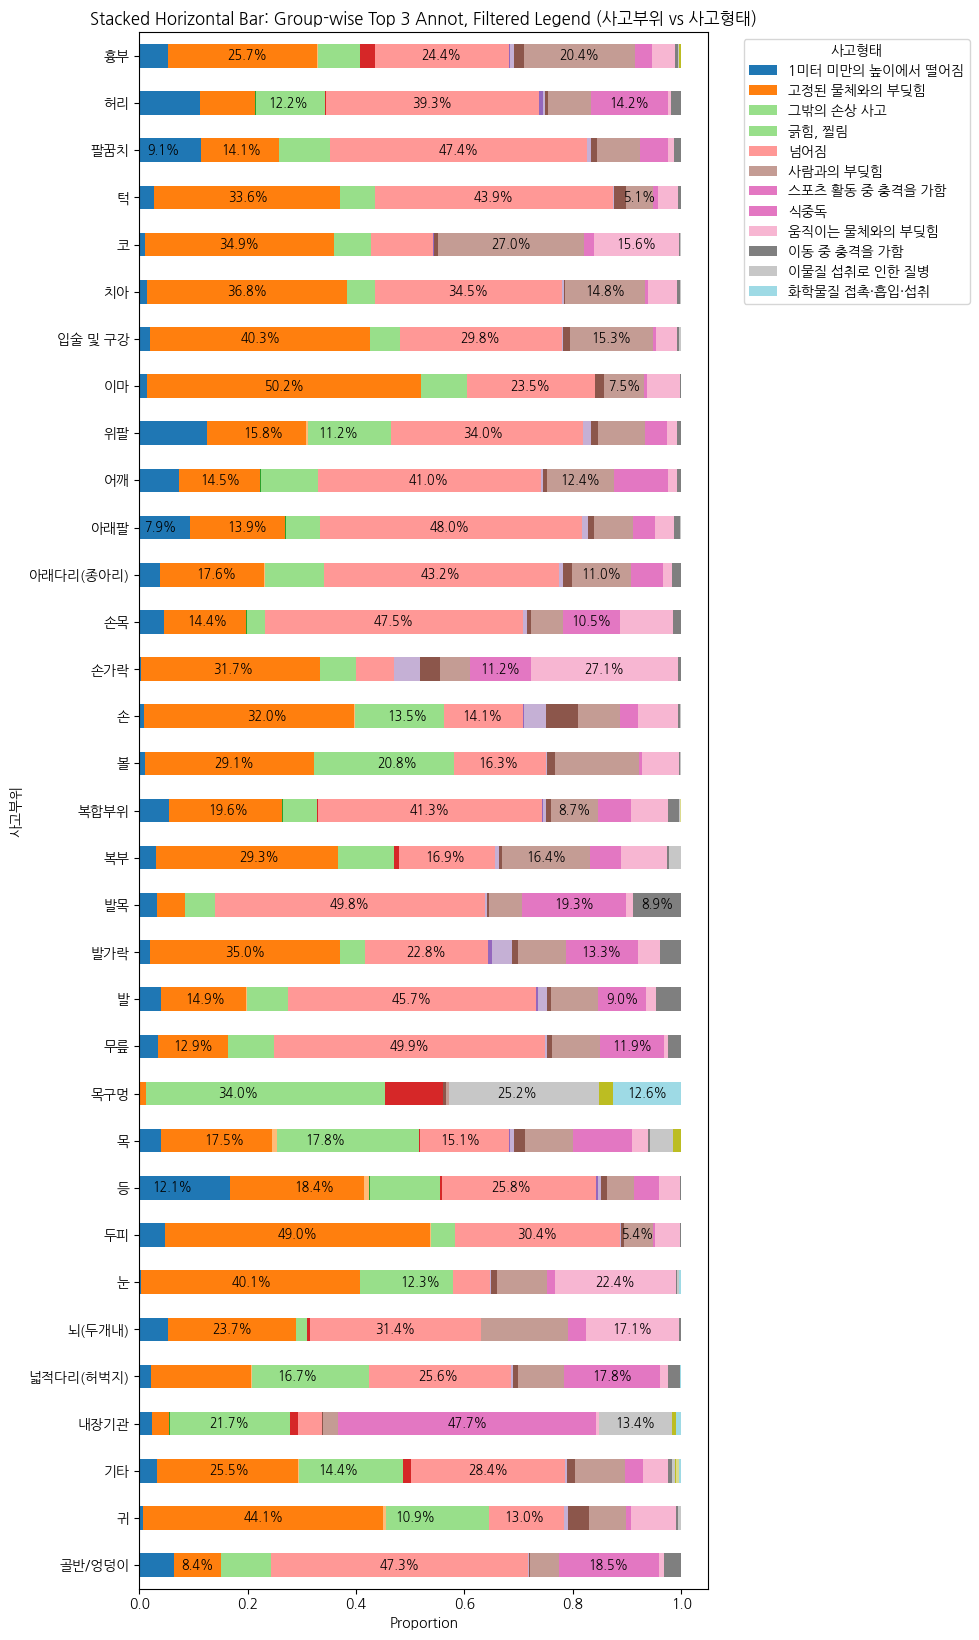

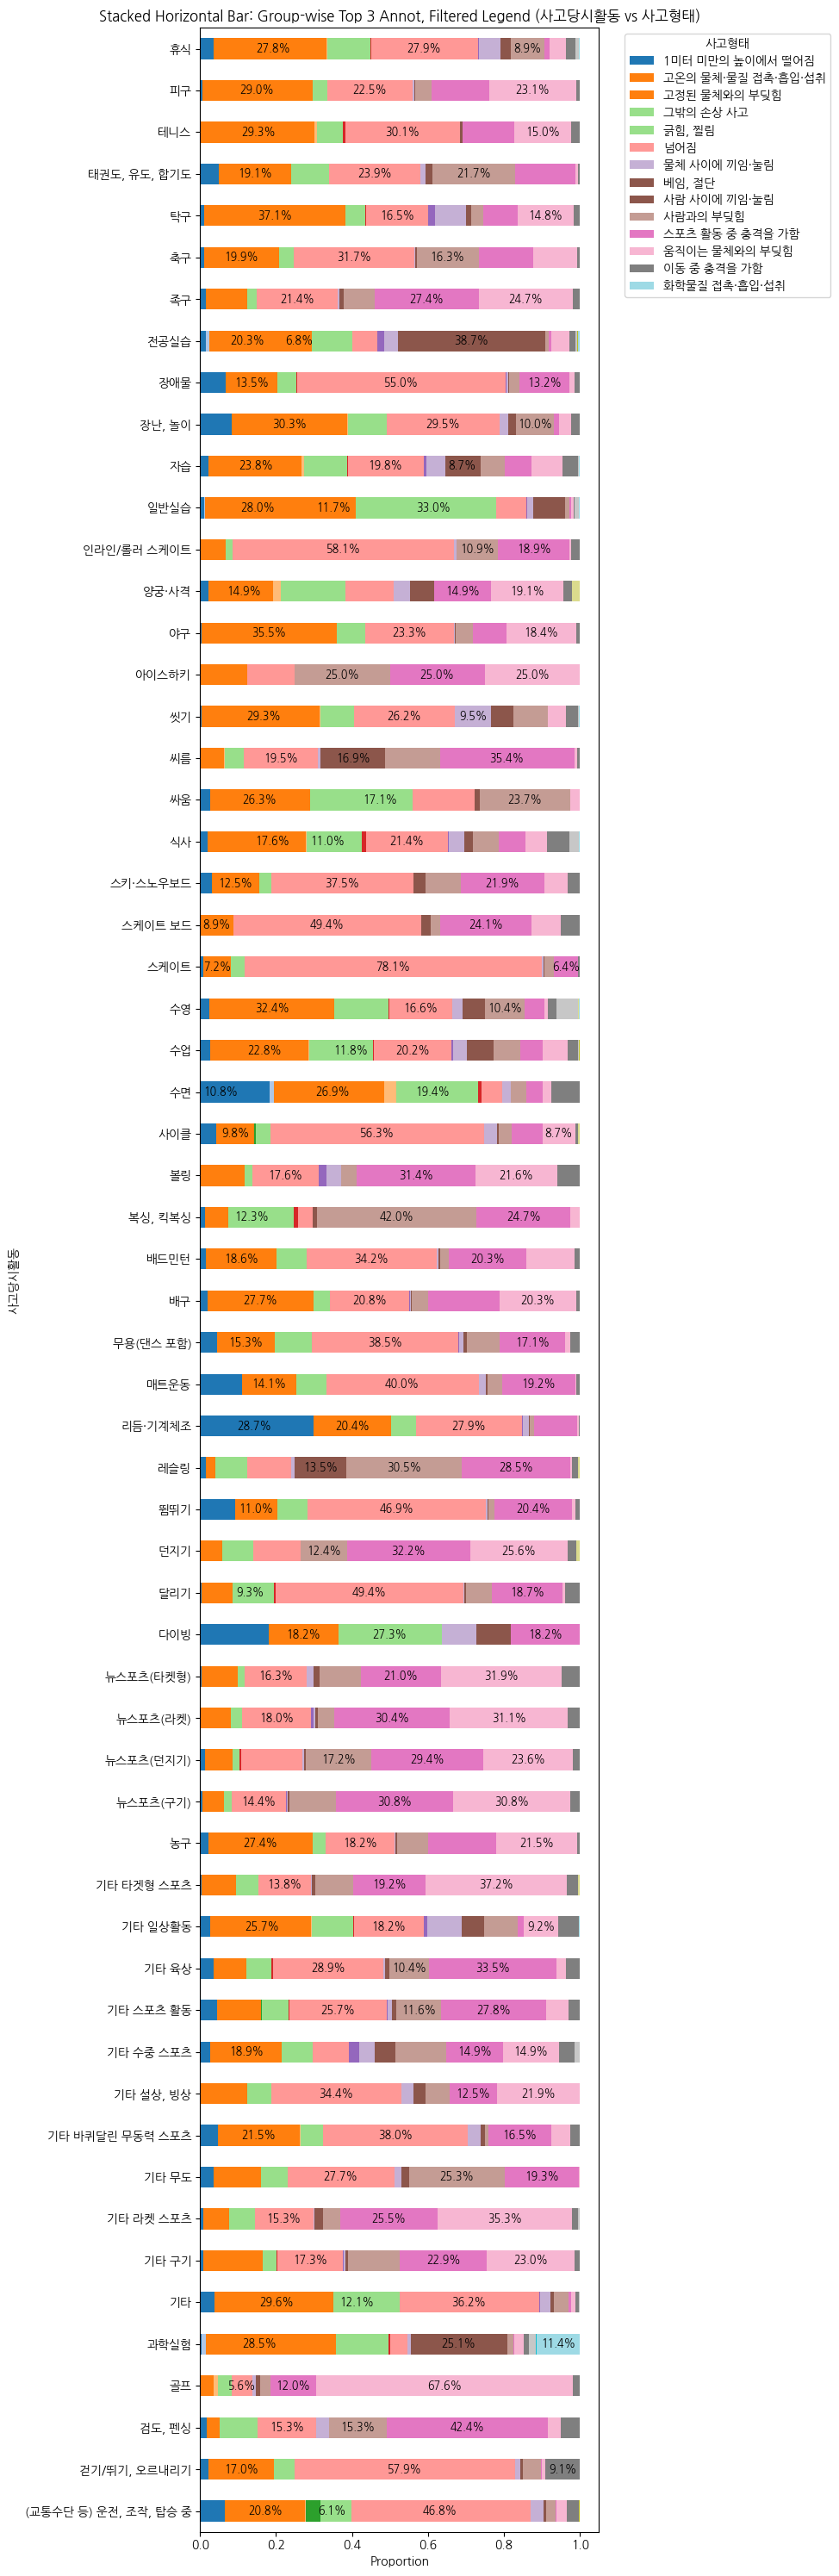

In [5]:
with_time = ['사고장소', '사고부위', '사고당시활동']

for i in with_time:
    cross_tab_top3(data, '사고형태', i)

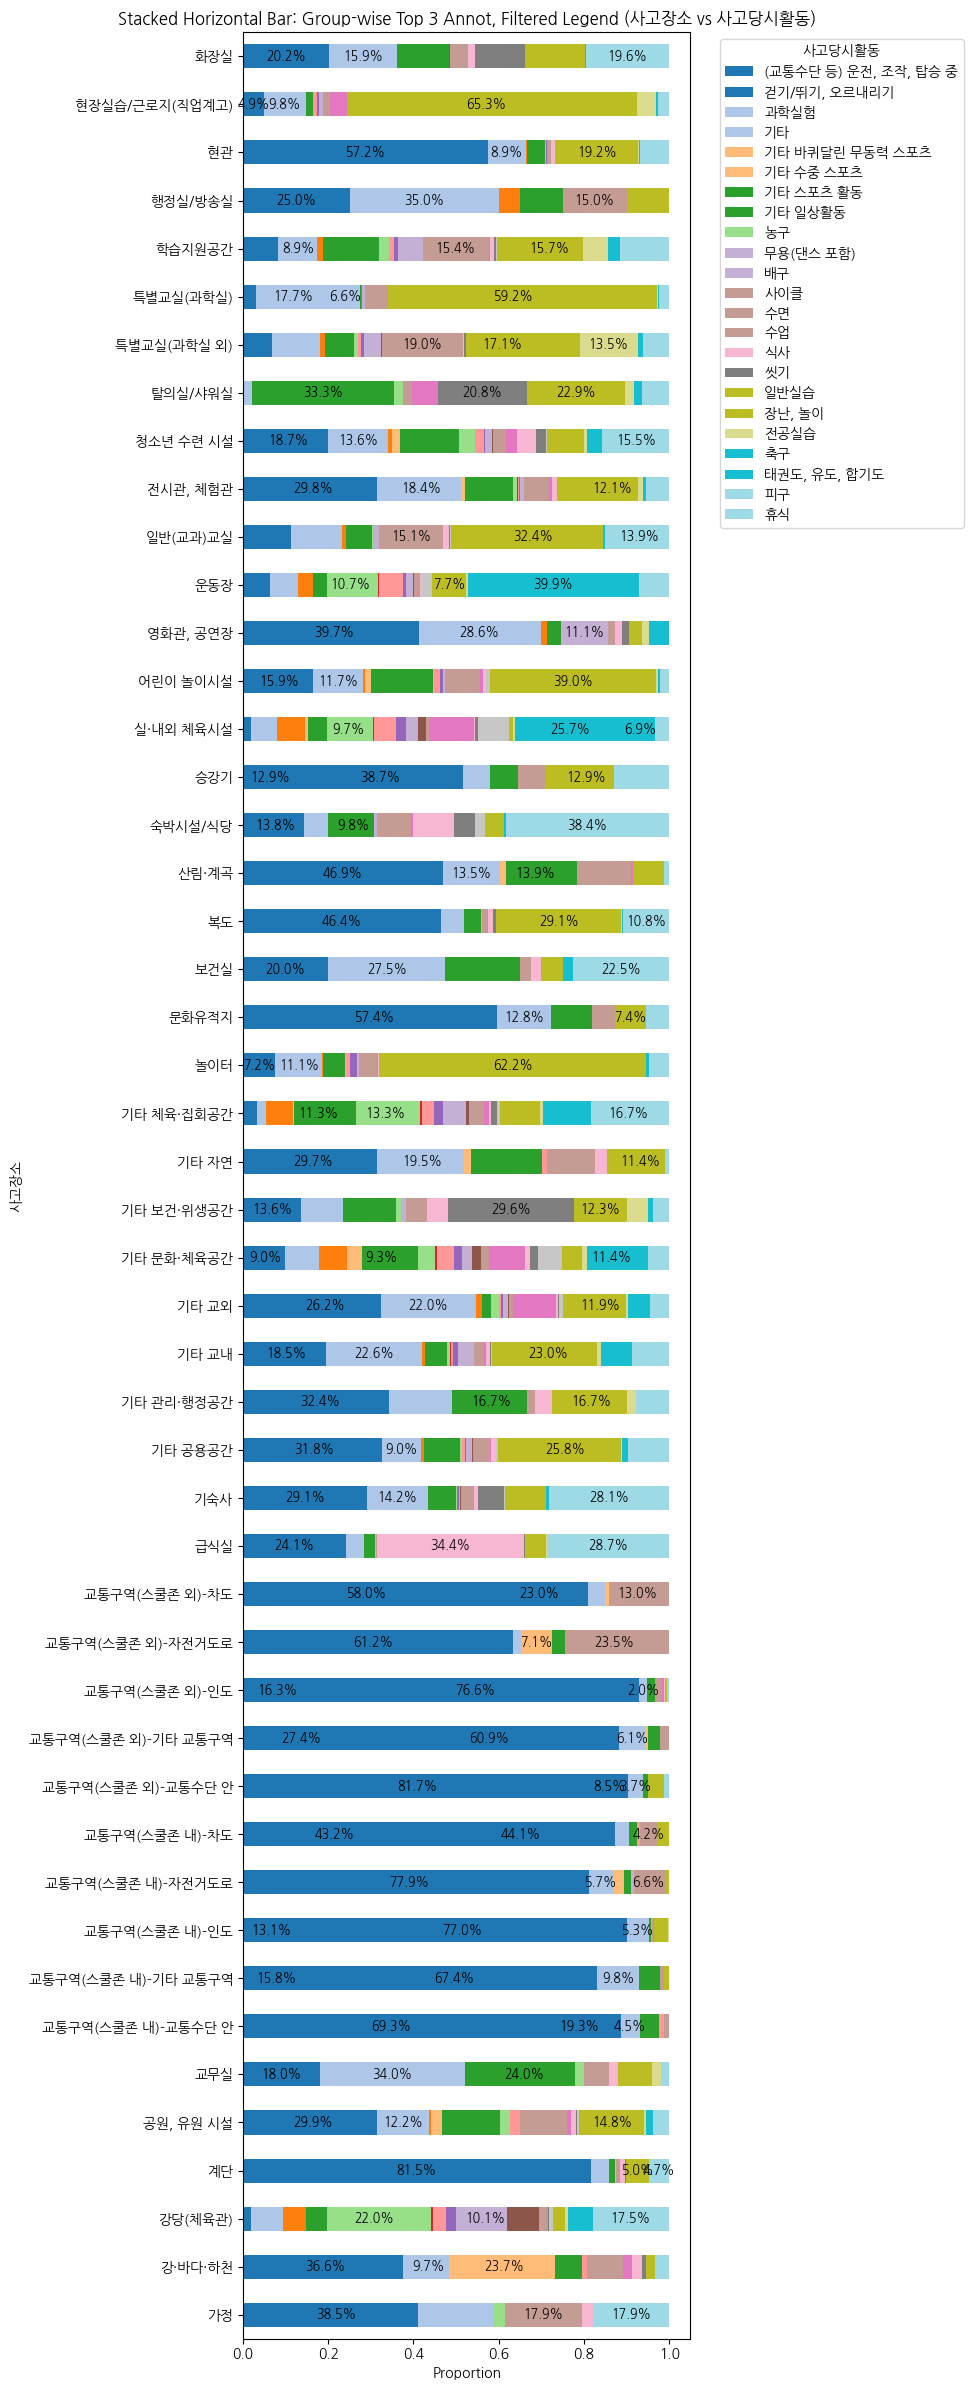

In [6]:
with_time = ['사고장소']

for i in with_time:
    cross_tab_top3(data, '사고당시활동', i)

# 차별점 찾기

In [7]:
def plot2(fdf):
    # 변수 구분
    categorical_vars = [col for col in fdf.columns if fdf[col].dtype == 'object' or fdf[col].dtype.name == 'category']
    numeric_vars = [col for col in fdf.columns if pd.api.types.is_integer_dtype(fdf[col])]
    
    # 시각화할 전체 변수 리스트
    all_vars = categorical_vars + numeric_vars
    
    # 레이아웃 설정
    n = len(all_vars)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols
    
    plt.figure(figsize=(6 * n_cols, 4 * n_rows))
    
    for idx, var in enumerate(all_vars, 1):
        plt.subplot(n_rows, n_cols, idx)
    
        if var in categorical_vars:
            # 범주형: 막대그래프
            fdf[var].value_counts().sort_index().plot(kind='bar', color='skyblue')
            plt.title(f'{var} Frequency')
            plt.xlabel(var)
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
            
        elif var in numeric_vars:
            # 정수형: 선그래프
            counts = fdf[var].value_counts().sort_index()
            plt.plot(counts.index, counts.values, marker='o', linestyle='-', color='tomato')
            plt.title(f'{var} Line Plot')
            plt.xlabel(var)
            plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

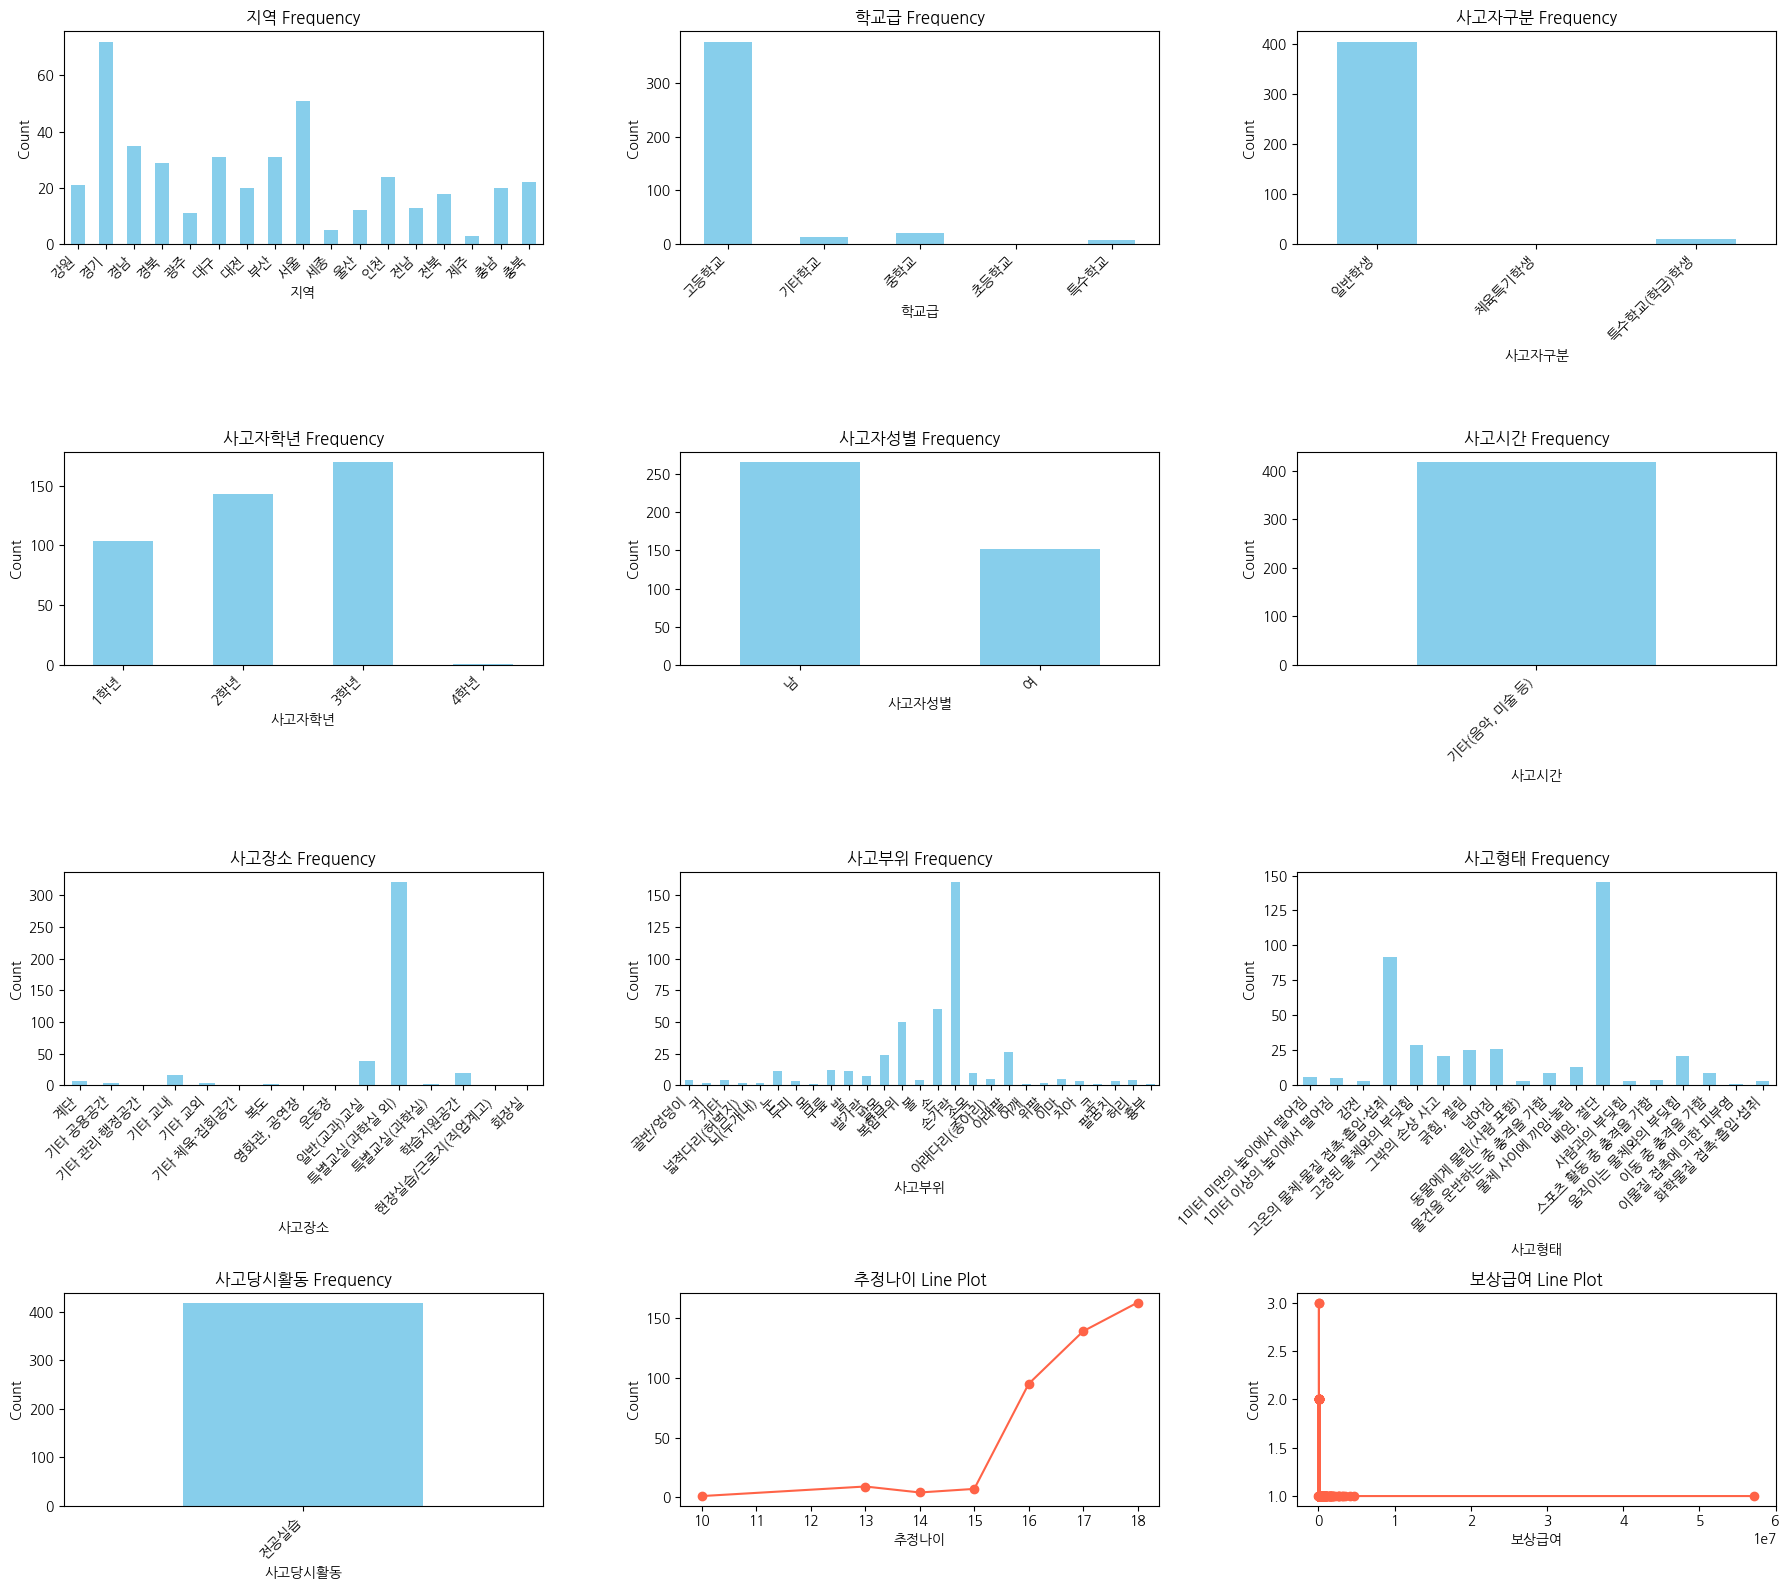

In [8]:
fdf = data[(data['사고당시활동'] == '전공실습') & (data['사고시간'] == '기타(음악, 미술 등)')]
plot2(fdf)

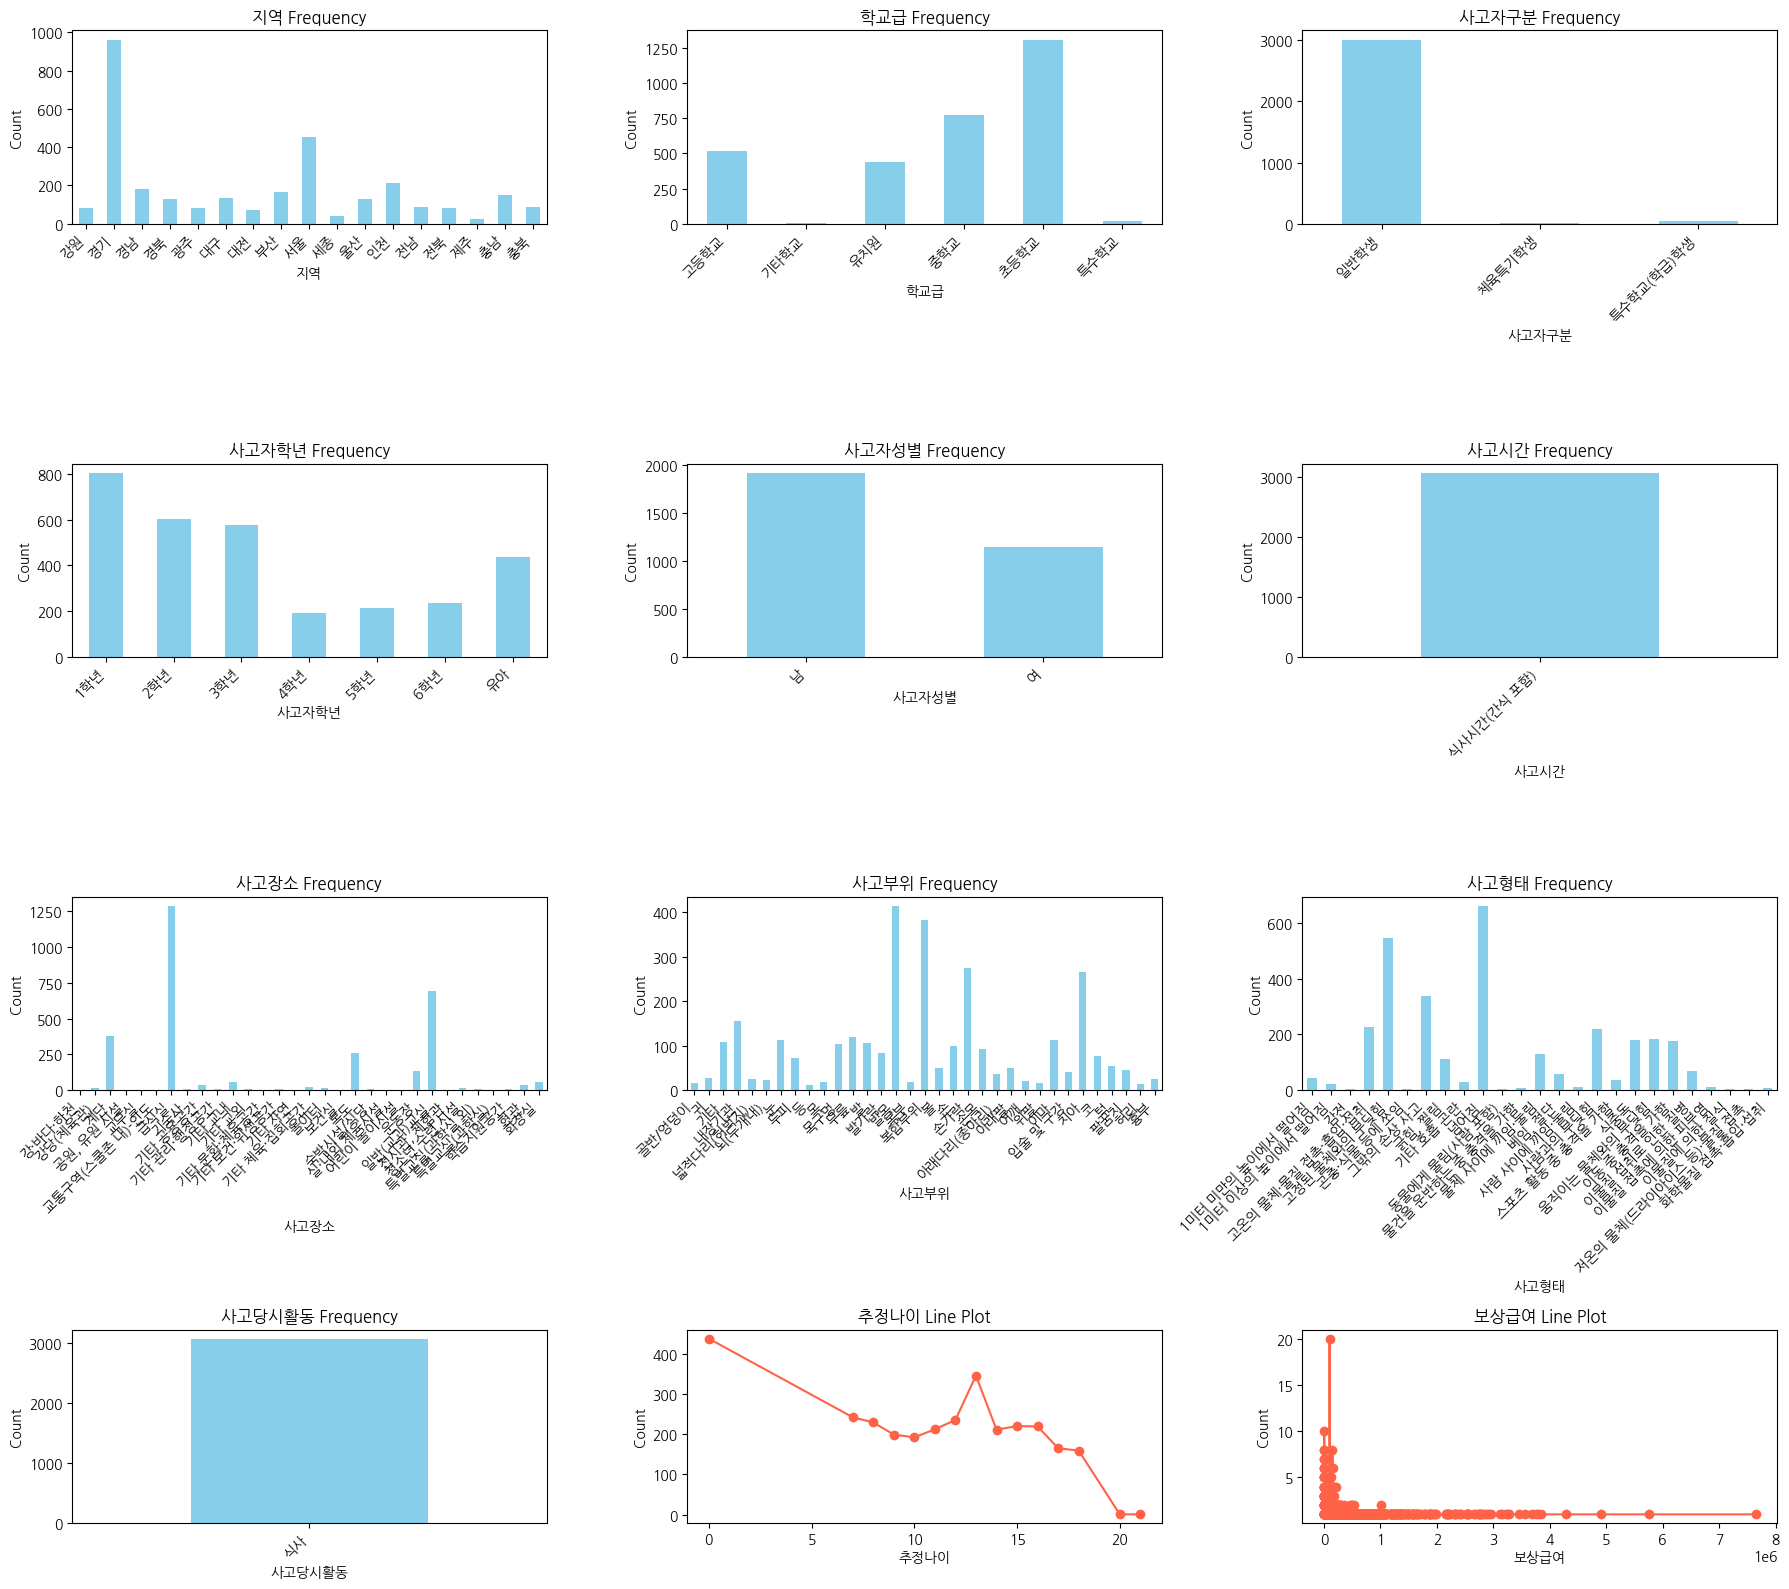

In [9]:
fdf2 = data[(data['사고당시활동'] == '식사') & (data['사고시간'] == '식사시간(간식 포함)')]
plot2(fdf2)

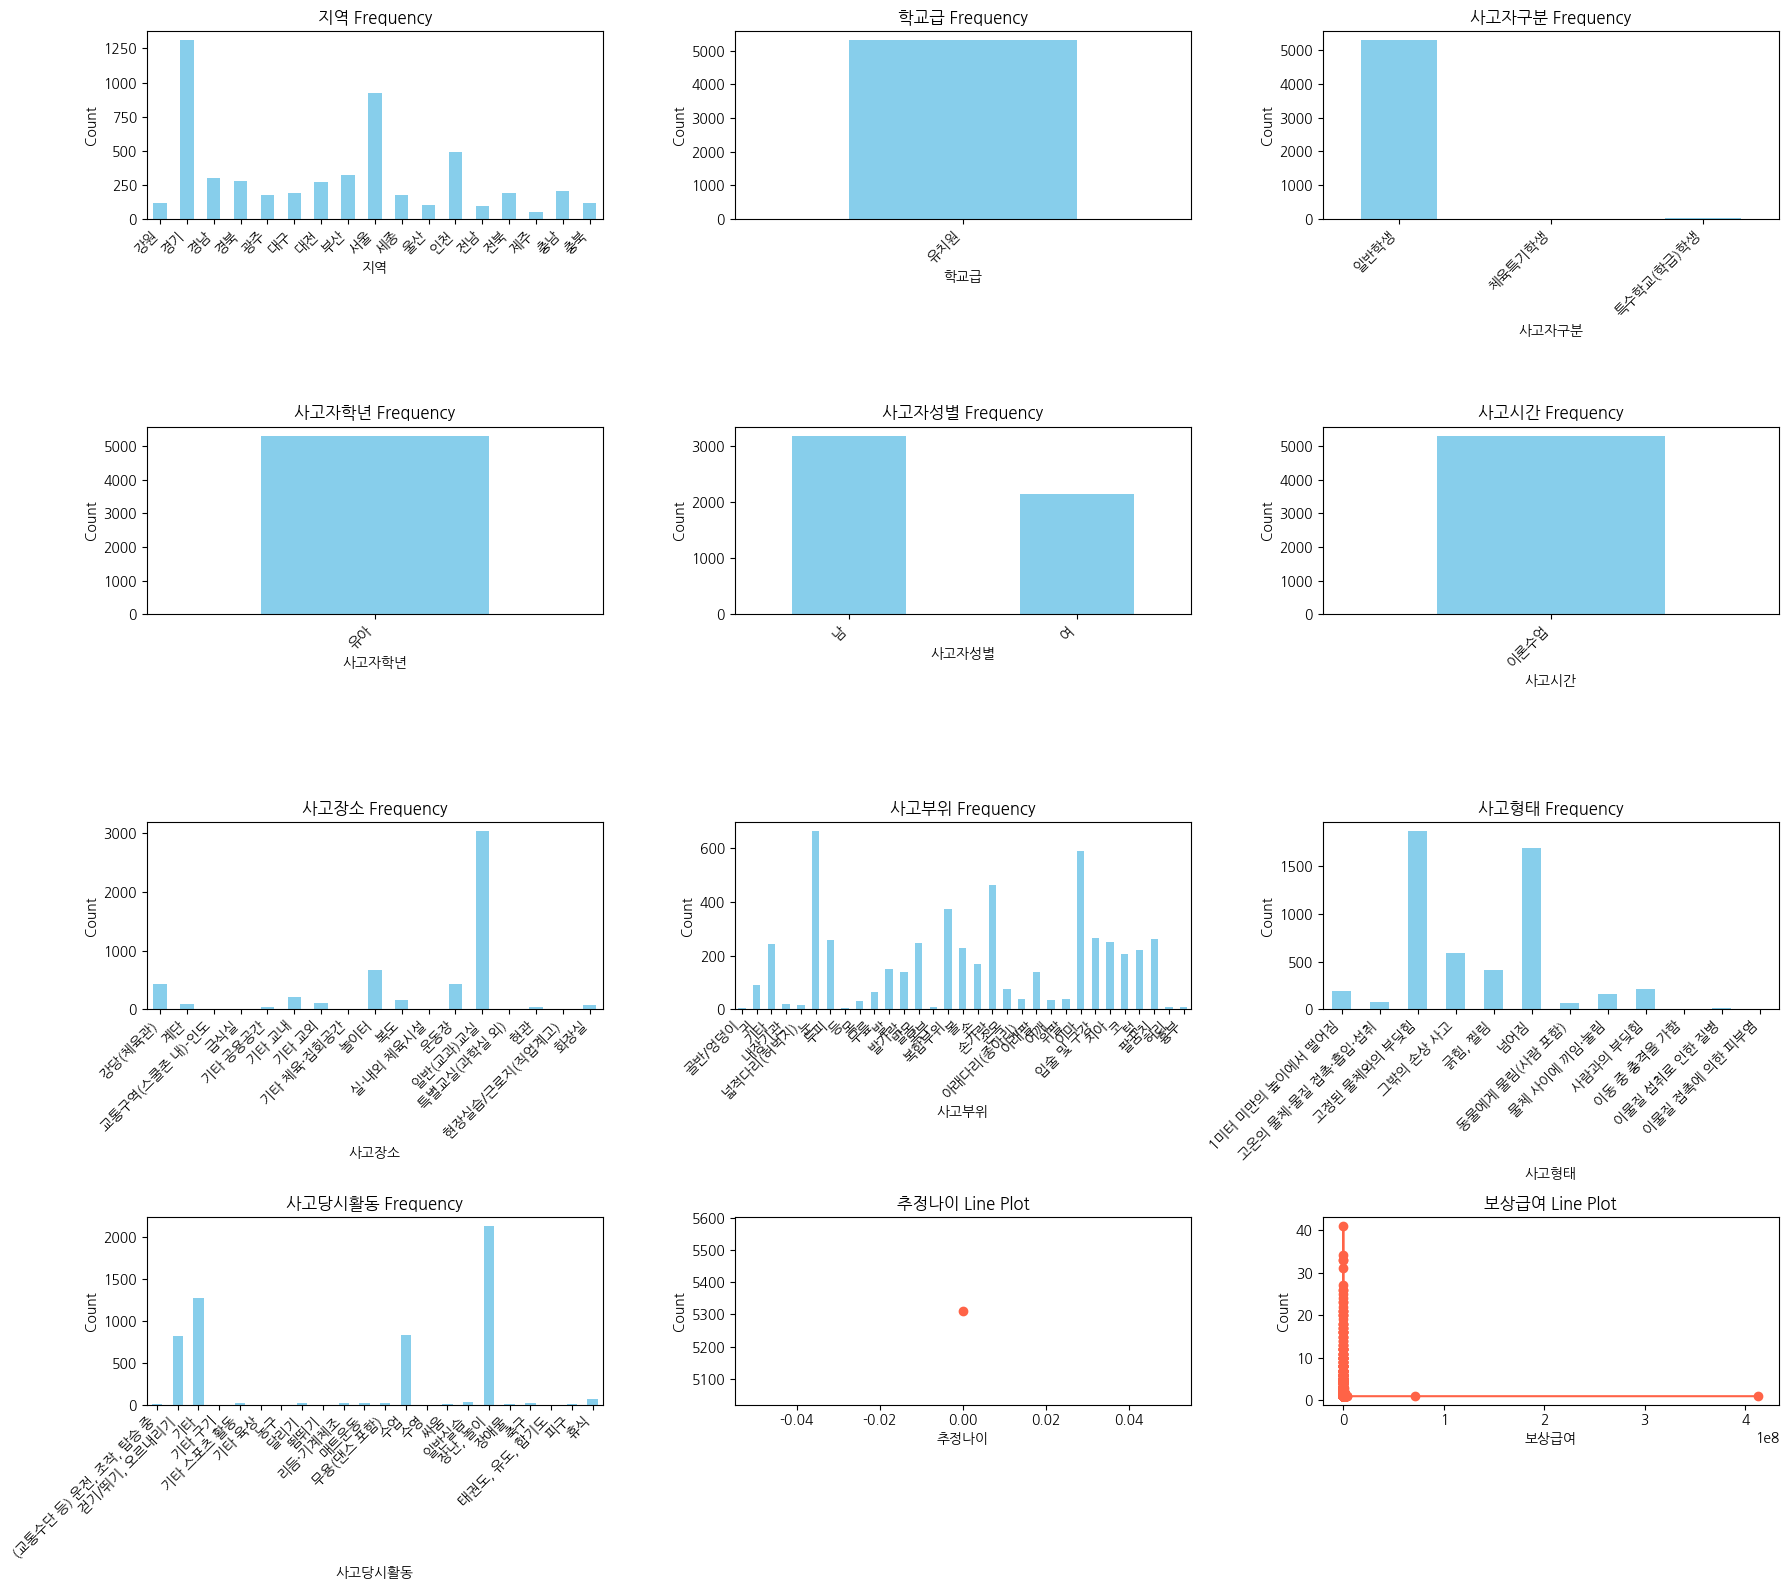

In [10]:
fdf3 = data[(data['학교급'] == '유치원') & (data['사고시간'] == '이론수업')]
plot2(fdf3)

In [ ]:
# 변수 구분
categorical_vars = [col for col in fdf2.columns if fdf[col].dtype == 'object' or fdf[col].dtype.name == 'category']
numeric_vars = [col for col in fdf.columns if pd.api.types.is_integer_dtype(fdf[col])]

# 시각화할 전체 변수 리스트
all_vars = categorical_vars + numeric_vars

# 레이아웃 설정
n = len(all_vars)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

plt.figure(figsize=(6 * n_cols, 4 * n_rows))

for idx, var in enumerate(all_vars, 1):
    plt.subplot(n_rows, n_cols, idx)

    if var in categorical_vars:
        # 범주형: 막대그래프
        fdf[var].value_counts().sort_index().plot(kind='bar', color='skyblue')
        plt.title(f'{var} Frequency')
        plt.xlabel(var)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        
    elif var in numeric_vars:
        # 정수형: 선그래프
        counts = fdf[var].value_counts().sort_index()
        plt.plot(counts.index, counts.values, marker='o', linestyle='-', color='tomato')
        plt.title(f'{var} Line Plot')
        plt.xlabel(var)
        plt.ylabel('Count')

plt.tight_layout()
plt.show()